## 05 - Analysis

In this notebook, we aim at exploring a bit the results we obtained from all the experiments that have been run so far.

We have ran a lot of experiments for a set amount of epochs, enough to basically converge, for both KANs and MLPs. We will focus on the following aspects:
- Compare the Approximate Mean Significance (AMS), Area Under the Curve (AUC), Accuracy and Binary Cross Entropy (BCE) of both models with regards to the number of neurons
- Compare the same metrics with regards to the number of parameters.
- Analyze the convergence speed of both models, to see if one of them tends to converge faster than the other. Both in terms of epochs and wall-clock time.

We will have to bear in mind that, because we trained for a fixed number of epochs, some models might not have fully converged yet. This is especially true for some of the KANs, which seem to converge following some weird patterns (Possibly they are more prone to falling into local minima?). For that reason, we will look at the rate of change of the metrics over the last few epochs, to get an idea of whether they have converged or not.


### Data Loading
Because we didn't log the results into a CSV or anything, and instead used MLflow, we will have to load all the data from it into a DataFrame with all the results we need.

> **IMPORTANT:** Before running the code, we have to make sure that the MLflow tracking URI environment variable is set to point to the right location where the experiments were logged.
> We'll do so by loading an env file that have to contain that variable. So **make sure to create a `.env` file right next to this notebook with the following**
> ```
> MLFLOW_TRACKING_URI="https://<username>:<password>@mlflow.parcerisa.xyz"
> ```

In [2]:
import dotenv

loaded = dotenv.load_dotenv(".env")  # Load environment variables from .env file
if not loaded:
    raise RuntimeError("Failed to load .env file. Please create one with the required environment variables.")

In [3]:
import mlflow
import pandas as pd

MLP_EXPERIMENT_NAME = "MLP Higgs Experiment"
KAN_EXPERIMENT_NAME = "KAN Higgs Experiment"

mlp_experiment = mlflow.get_experiment_by_name(MLP_EXPERIMENT_NAME)
if not mlp_experiment:
    raise ValueError(f"Experiment '{MLP_EXPERIMENT_NAME}' not found in MLflow.")
kan_experiment = mlflow.get_experiment_by_name(KAN_EXPERIMENT_NAME)
if not kan_experiment:
    raise ValueError(f"Experiment '{KAN_EXPERIMENT_NAME}' not found in MLflow.")

mlp_runs = mlflow.search_runs(experiment_ids=[mlp_experiment.experiment_id])
kan_runs = mlflow.search_runs(experiment_ids=[kan_experiment.experiment_id])

if not isinstance(mlp_runs, pd.DataFrame) or mlp_runs.empty:
    raise ValueError(f"No runs found for experiment '{MLP_EXPERIMENT_NAME}'.")
if not isinstance(kan_runs, pd.DataFrame) or kan_runs.empty:
    raise ValueError(f"No runs found for experiment '{KAN_EXPERIMENT_NAME}'.")

mlp_runs = mlp_runs[mlp_runs["status"] == "FINISHED"]
kan_runs = kan_runs[kan_runs["status"] == "FINISHED"]

print(f"MLP Experiment '{MLP_EXPERIMENT_NAME}' has {len(mlp_runs)} runs.")
print(f"KAN Experiment '{KAN_EXPERIMENT_NAME}' has {len(kan_runs)} runs.")

mlp_runs["model_type"] = "MLP"
kan_runs["model_type"] = "KAN"
df = pd.concat([mlp_runs, kan_runs], ignore_index=True)

MLP Experiment 'MLP Higgs Experiment' has 140 runs.
KAN Experiment 'KAN Higgs Experiment' has 141 runs.


Now let's clean the DataFrame and set the types

In [4]:
df.drop(
    columns=[
        "experiment_id",
        "status",
        "artifact_uri",
        "params.metrics",
        "tags.mlflow.source.git.commit",
        "tags.mlflow.source.name",
        "tags.mlflow.runName",
        "tags.mlflow.user",
        "tags.mlflow.runColor",
        "tags.mlflow.source.type",
    ],
    inplace=True,
)
df["params.batch_size"] = df["params.batch_size"].astype("Int64")
df["params.optimizer"] = df["params.optimizer"].astype("category")
df["params.seed"] = df["params.seed"].astype("Int64")
df["params.epochs"] = df["params.epochs"].astype("Int64")
df["params.random_state"] = df["params.random_state"].astype("Int64")
df["params.cv_fold_index"] = df["params.cv_fold_index"].astype("Int64")
df["params.cv_folds"] = df["params.cv_folds"].astype("Int64")
df["params.loss_fn"] = df["params.loss_fn"].astype("category")
df["params.hidden_dim"] = df["params.hidden_dim"].astype("Int64")
df["params.shuffle"] = df["params.shuffle"].apply(lambda x: x.lower() == "true").astype("boolean")
df["params.learning_rate"] = df["params.learning_rate"].astype("float")
df["params.num_features"] = df["params.num_features"].astype("Int64")  # Number of input features
df["params.l1_reg"] = df["params.l1_reg"].astype("float")
df["model_type"] = df["model_type"].astype("category")
# KAN-specific parameters
df["params.reg_metric"] = df["params.reg_metric"].astype("category")
df["params.lamb_entropy"] = df["params.lamb_entropy"].astype("float")
df["params.y_th"] = df["params.y_th"].astype("float")
df["params.singularity_avoiding"] = (
    df["params.singularity_avoiding"].apply(lambda x: isinstance(x, str) and x.lower() == "true").astype("boolean")
)
df["params.k"] = df["params.k"].astype("Int64")
df["params.lamb"] = df["params.lamb"].astype("float")
df["params.grid"] = df["params.grid"].astype("Int64")
df["params.lamb_coef"] = df["params.lamb_coef"].astype("float")
df["params.lamb_coefdiff"] = df["params.lamb_coefdiff"].astype("float")

These DataFrames contain the "final" results of each experiment, i.e., the results at the last epoch, as well as the hyperparameters used for each experiment. If at some point we need the full history of each experiment, we can always load it from MLflow again.

### Filtering Fully Trained Models

Before we perform any analysis, let us create two new filtered Data Frames that only contain the models that have fully converged. For that, let us obtain the rate of change of AMS, AUC, Accuracy and BCE over the last 5 epochs for all models.

In [5]:
# Before we extract the final metrics, let us explore the available metrics for each run
all_metrics = set()
for run_id in df["run_id"].tolist():
    run = mlflow.get_run(run_id)
    all_metrics.update(run.data.metrics.keys())

print("Available metrics across all runs:")
for metric in sorted(all_metrics):
    print(f"- {metric}")

Available metrics across all runs:
- train_loss_batch
- train_loss_epoch
- val_accuracy_epoch
- val_ams_epoch
- val_auc_epoch
- val_loss_epoch


We are interested only on the validation metrics, specifically:
- val_accuracy_epoch
- val_ams_epoch
- val_auc_epoch
- val_loss_epoch

These have the suffix "_epoch" to indicate that they are logged at the end of each epoch, as opposed to "_batch", which are logged after each batch.

In [6]:
val_metric_names = ["val_accuracy_epoch", "val_ams_epoch", "val_auc_epoch", "val_loss_epoch"]

In [7]:
from collections import defaultdict
from typing import Dict
import pandas as pd
from mlflow.tracking import MlflowClient
from tqdm.auto import tqdm

# To obtain the metric history, we need to go one layer deeper into MLflow
client = MlflowClient()

metric_histories: Dict[str, pd.DataFrame] = {}
for j, run_row in tqdm(df.iterrows(), leave=False, desc=f"Getting histories", total=len(df)):
    data = {}
    max_epoch = 0
    for metric in val_metric_names:
        history = client.get_metric_history(run_row["run_id"], metric)
        data[metric] = pd.DataFrame.from_records(
            [(m.step, m.timestamp, m.value) for m in history], columns=["epoch", "timestamp", metric]
        )
        max_epoch = max(max_epoch, data[metric]["epoch"].max())
    # Now we need to merge all dataframes on epoch
    merged_df = pd.DataFrame({"epoch": range(1, max_epoch + 1), "timestamp": pd.NaT})
    for metric in val_metric_names:
        merged_df = merged_df.merge(data[metric], on="epoch", how="left", suffixes=("", f"_{metric}"))
    # Now average all the available timestamps. This is a bit hacky, but should work fine.
    merged_df["timestamp"] = merged_df[[col for col in merged_df.columns if col.startswith("timestamp")]].mean(axis=1)
    # Finally, drop the extra timestamp columns
    merged_df = merged_df[["epoch", "timestamp"] + val_metric_names]
    metric_histories[run_row["run_id"]] = merged_df

Getting histories:   0%|          | 0/281 [00:00<?, ?it/s]

Now that we have obtained all the histories, we are interested in the slope of the last 5 epochs. To do so, we will simply perform a linear regression over the last 5 points of each metric, and obtain the slope of the fitted line.

In [8]:
from sklearn.linear_model import LinearRegression


def get_slope_of_last_n_epochs(row: pd.Series, metric: str, n: int = 5) -> float:
    """Compute the slope of the last n epochs for a given metric using linear regression."""
    df = metric_histories[row["run_id"]]

    last_n = df.dropna(subset=[metric]).sort_values(by="epoch").tail(n)
    if len(last_n) < 2:
        return float("nan")  # Not enough data to compute slope

    X = last_n["epoch"].values.reshape(-1, 1)
    y = last_n[metric].values

    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0]


for metric in val_metric_names:
    slope_column = f"{metric}_slope"
    df[slope_column] = df.apply(lambda row: get_slope_of_last_n_epochs(row, metric), axis=1)

Finally, before manually setting a threshold for convergence, let us first explore the distribution of slopes for both models.

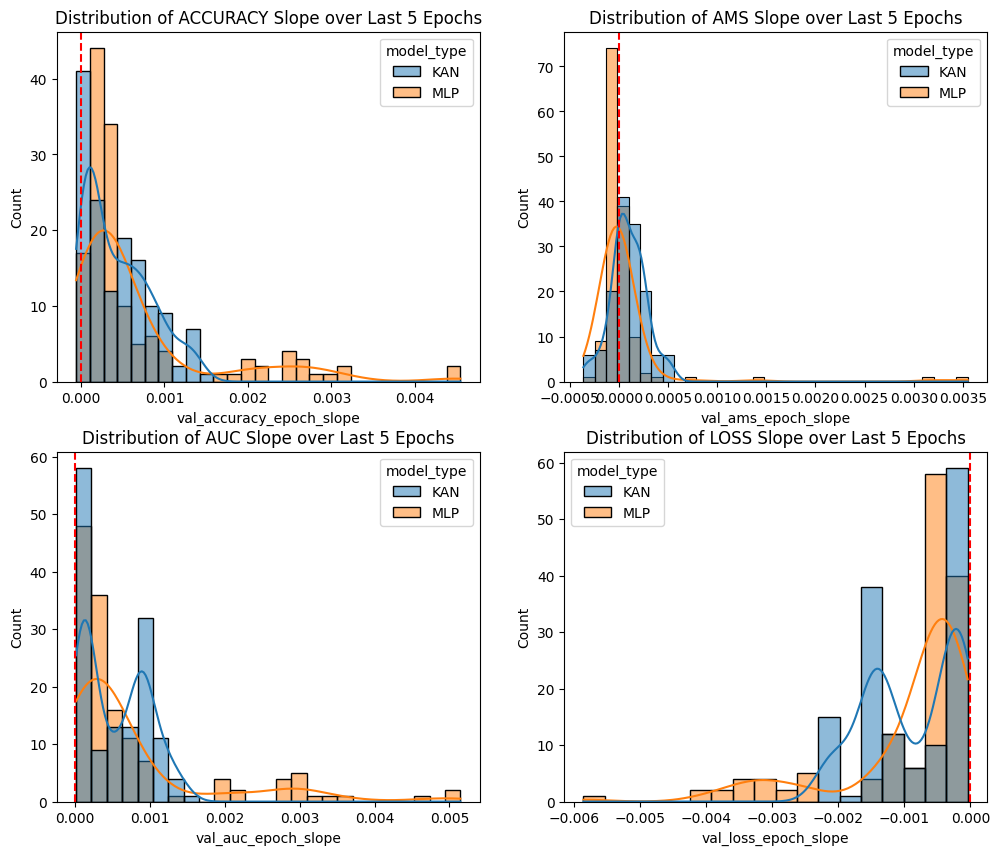

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i, metric in enumerate(val_metric_names):
    r = i // 2
    c = i % 2
    slope_column = f"{metric}_slope"
    sns.histplot(data=df, x=slope_column, fill=True, alpha=0.5, hue="model_type", ax=ax[r, c], color="blue", kde=True)
    metric_name = metric.replace("val_", "").replace("_epoch", "").upper()
    ax[r, c].set_title(f"Distribution of {metric_name} Slope over Last 5 Epochs")
    ax[r, c].axvline(0, color="red", linestyle="--", label="Zero Slope")

As expected, most models have slopes close to zero, indicating they converged. However, some models (especially MLPs) didn't quite converge all the way. Also, as expected, for ACCURACY and AUC, the slopes are all positive (we want these metrics to increase over time), while LOSS has all negative slopes (we want the loss to decrease over time). AMS is a bit more mixed, as some models have positive slopes while others have negative ones.

This suggests that models had reached a peak AMS value and then started to fluctuate around it by the end of their trainings.

So, we'll arbitrarily set the following thresholds for convergence:
- |slope| < 0.0015 for ACCURACY.
- |slope| < 0.0005 for AMS.
- |slope| < 0.0015 for AUC.
- |slope| < 0.002 for LOSS.
These threshold seem to separate well the "bulk" of converged models from the long tails of non-converged ones, primarily for MLPs.

We will explore the non-converged models later, because they might provide some insights (we expect those to mostly be MLPs with 1 or 2 neurons on the hidden layer).

In [10]:
thresholds = {
    "val_accuracy_epoch": 0.0015,
    "val_ams_epoch": 0.0005,
    "val_auc_epoch": 0.0015,
    "val_loss_epoch": 0.002,
}
for metric in val_metric_names:
    df[f"{metric}_converged"] = df[f"{metric}_slope"].abs() < thresholds[metric]

# Compute the final is_outlier mask
converged_columns = [f"{metric}_converged" for metric in val_metric_names]
df["converged"] = df[converged_columns].all(axis=1)
print(f"Number of non-converged models detected: {(~df['converged']).sum()} out of {len(df)}")

Number of non-converged models detected: 38 out of 281


With these thresholds, we lost 38 rows out of the 281 total we had (~13.5%), which is acceptable. Now, if we look at the distribution of parameters that didn't converge:

In [11]:
df[~df["converged"]][["model_type", "params.hidden_dim"]].value_counts().reset_index(name="count")

,model_type,params.hidden_dim,count
0,KAN,2,5
1,KAN,32,5
2,KAN,100,5
3,MLP,2,5
4,MLP,4,5
5,MLP,16,5
6,MLP,8,5
7,KAN,1024,2
8,MLP,3,1


In [12]:
df[~df["converged"]][["model_type"]].value_counts().reset_index(name="count")

,model_type,count
0,MLP,21
1,KAN,17


We can see that, as expected, pretty much all the MLPs with a small amount of neurons didn't converge. Surprisingly, we also find MLPs with 16 hidden neurons that also didn't converge, and most surprisingly, we find also lots of KANs with a lot of hidden parameters that didn't converge.

Let us explore the evolution of those non-converged models:

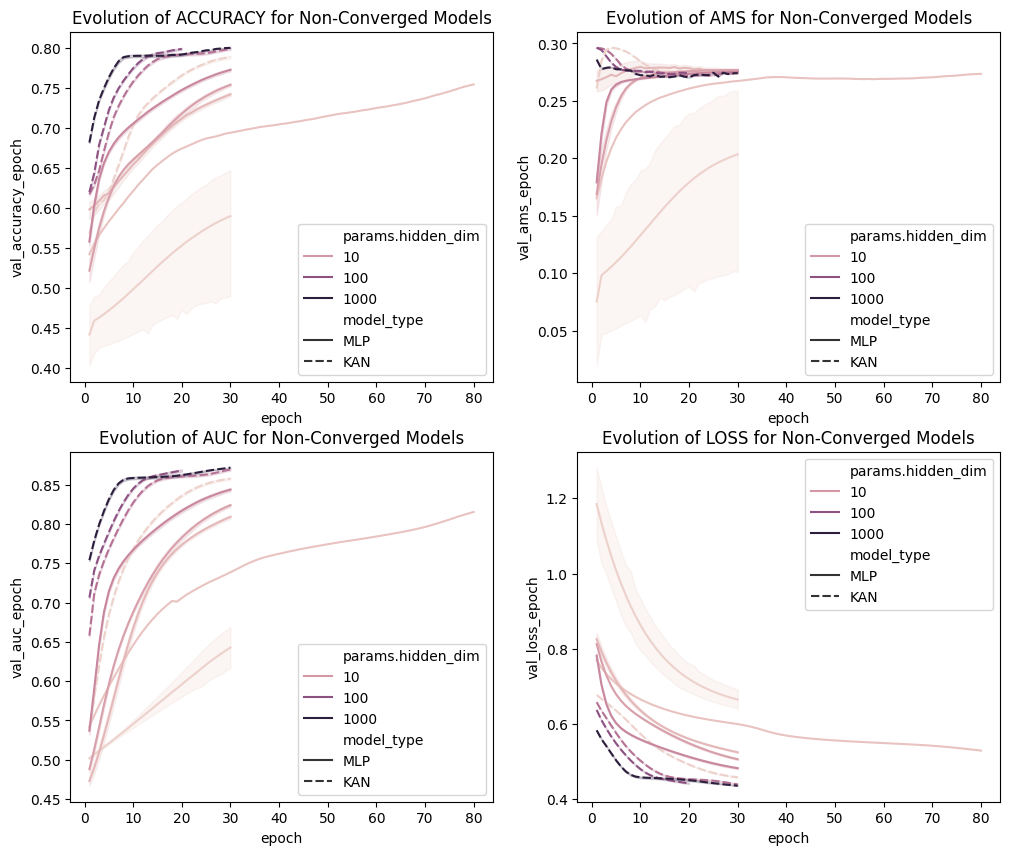

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

all_histories = None
for j, row in df[~df["converged"]].iterrows():
    history = metric_histories[row["run_id"]].copy()
    history["model_type"] = row["model_type"]
    history["params.hidden_dim"] = row["params.hidden_dim"]
    history["run_id"] = row["run_id"]
    if all_histories is None:
        all_histories = history
    else:
        all_histories = pd.concat([all_histories, history], ignore_index=True)


for i, metric in enumerate(val_metric_names):
    r = i // 2
    c = i % 2
    sns.lineplot(
        data=all_histories,
        x="epoch",
        y=metric,
        hue="params.hidden_dim",
        hue_norm=LogNorm(),  # For visualization (I tried lin scale but it was all white and a single black)
        style="model_type",
        estimator="mean",
        ax=ax[r, c],
    )
    metric_name = metric.replace("val_", "").replace("_epoch", "").upper()
    ax[r, c].set_title(f"Evolution of {metric_name} for Non-Converged Models")

It looks like it's true, most of these didn't converge at all. Interestingly, some KANs look like they felt into local minima, but didn't get stuck completely, that's why they seem to have a second descent after some point. This could be an interesting aspect to explore further in the future. (See OpenAI's Double Descent paper, I don't think that this is the same thing, but it could be related).

Finally, a note to relax the reader, I see that most of the non-converged models are from experiments that didn't get past epoch 30. This is from a first batch of experiments that I ran, where I preemptively decided to set max epochs to 30 thinking that would be enough, but later I decided to be smarter and set it to 50 for those that didn't seem to converge. So, we shouldn't have lost much information from these non-converged models.

### AMS as a function of Neurons

Finally, with the converged models, let us start analyzing the metrics we obtained.

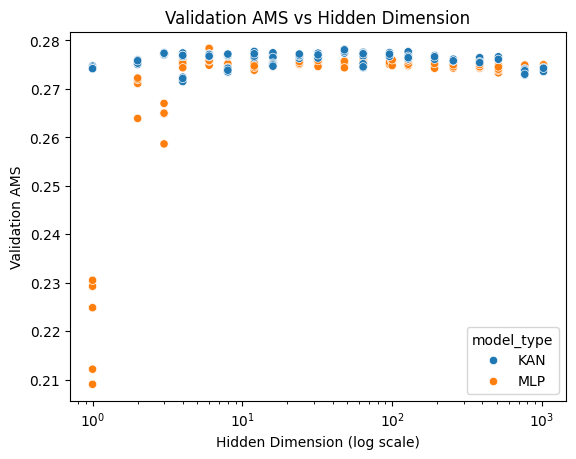

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="params.hidden_dim",
    y="metrics.val_ams_epoch",
    hue="model_type",
)
plt.title("Validation AMS vs Hidden Dimension")
plt.xlabel("Hidden Dimension (log scale)")
plt.ylabel("Validation AMS")
plt.xscale("log")

### AUC as a function of Neurons

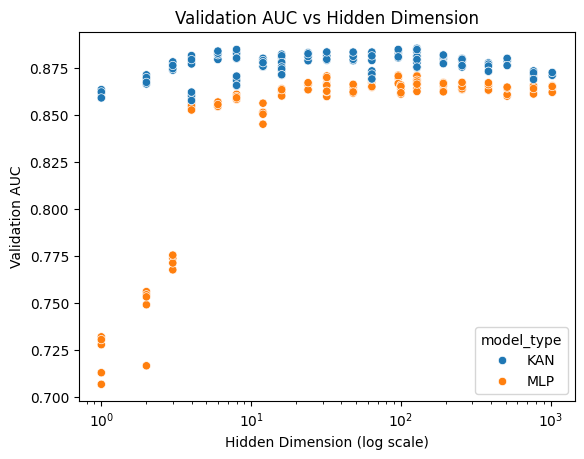

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="params.hidden_dim",
    y="metrics.val_auc_epoch",
    hue="model_type",
)
plt.title("Validation AUC vs Hidden Dimension")
plt.xlabel("Hidden Dimension (log scale)")
plt.ylabel("Validation AUC")
plt.xscale("log")

### Accuracy as a function of Neurons

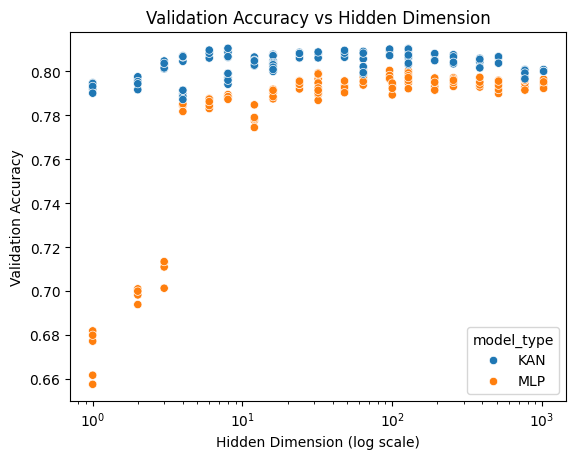

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="params.hidden_dim",
    y="metrics.val_accuracy_epoch",
    hue="model_type",
)
plt.title("Validation Accuracy vs Hidden Dimension")
plt.xlabel("Hidden Dimension (log scale)")
plt.ylabel("Validation Accuracy")
plt.xscale("log")

### Binary Cross Entropy as a function of Neurons

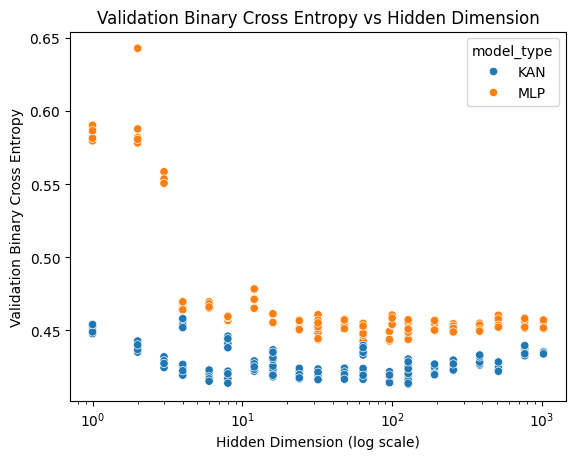

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="params.hidden_dim",
    y="metrics.val_loss_epoch",
    hue="model_type",
)
plt.title("Validation Binary Cross Entropy vs Hidden Dimension")
plt.xlabel("Hidden Dimension (log scale)")
plt.ylabel("Validation Binary Cross Entropy")
plt.xscale("log")

### AMS as a function of Parameters

To compute things as a function of parameters, we first need to compute the total number of parameters for each model. This is easy to do, as we know the formulas for both MLPs and KANs.

All MLP models had the same architecture:
- Input Layer: 17 features (We have a column in the dataset that specifies this)
- Hidden Layer: params.hidden_dim neurons
- Activation: ReLU
- Output Layer: 1 neuron (Binary classification)
- Activation: Sigmoid
All the layers are fully connected and have biases.

This means that the total number of parameters for MLPs is given by:
```python
total_params_MLP = (input_dim + 1) * hidden_dim + (hidden_dim + 1) * output_dim
```

And all KAN models had the following architecture:
- Input Layer: 17 features
- Edges: KAN (With params.grid intervals of degree params.k and a scalable base function)
- Hidden Layer: params.hidden_dim neurons
- Edges: KAN (With params.grid intervals of degree params.k and a scalable base function)
- Output Layer: 1 neuron (Binary classification)
- Activation: Sigmoid (We have a final Sigmoid activation to get probabilities)

This means that the total number of parameters for KANs is given by:
```python
total_params_KAN = (input_dim * hidden_dim) * (grid + k + 1) + (hidden_dim * output_dim) * (grid + k + 1)
```
Now that we have computed the total number of parameters for each model, we can proceed to analyze the metrics as a function of parameters.


In [18]:
def compute_num_params(row, output_dim: int = 1) -> int:
    input_dim = row["params.num_features"]
    hidden_dim = row["params.hidden_dim"]
    if row["model_type"] == "MLP":
        return (input_dim + 1) * hidden_dim + (hidden_dim + 1) * output_dim
    elif row["model_type"] == "KAN":
        grid = row["params.grid"]
        k = row["params.k"]
        return (input_dim * hidden_dim) * (grid + k + 1) + (hidden_dim * output_dim) * (grid + k + 1)
    else:
        raise ValueError(f"Unknown model type: {row['model_type']}")


df["num_params"] = df.apply(compute_num_params, axis=1)

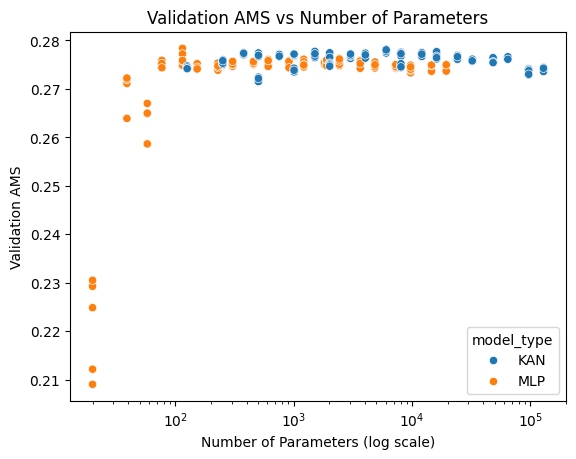

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="num_params",
    y="metrics.val_ams_epoch",
    hue="model_type",
)
plt.title("Validation AMS vs Number of Parameters")
plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Validation AMS")
plt.xscale("log")

### AUC as a function of Parameters

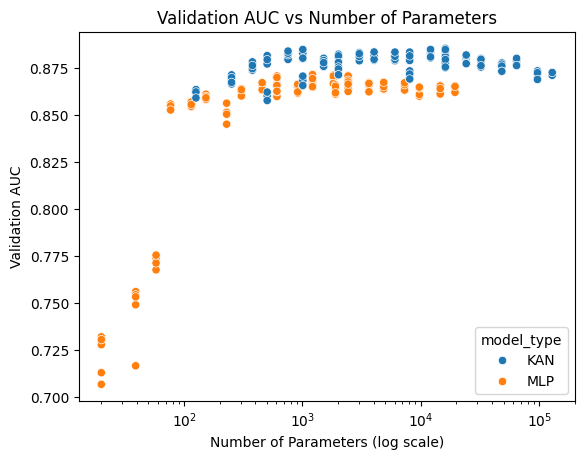

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="num_params",
    y="metrics.val_auc_epoch",
    hue="model_type",
)
plt.title("Validation AUC vs Number of Parameters")
plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Validation AUC")
plt.xscale("log")

### Accuracy as a function of Parameters

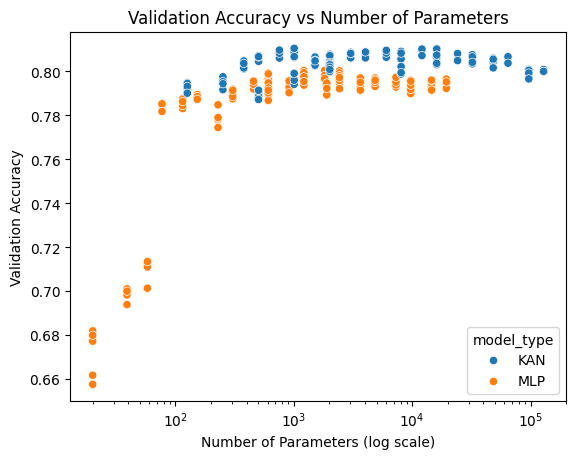

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="num_params",
    y="metrics.val_accuracy_epoch",
    hue="model_type",
)
plt.title("Validation Accuracy vs Number of Parameters")
plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Validation Accuracy")
plt.xscale("log")

### Binary Cross Entropy as a function of Parameters

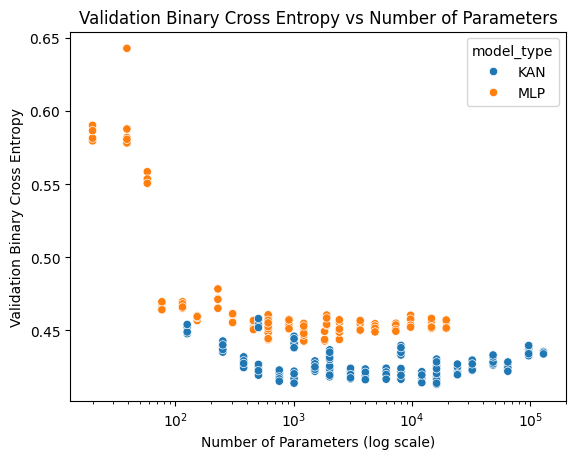

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="num_params",
    y="metrics.val_loss_epoch",
    hue="model_type",
)
plt.title("Validation Binary Cross Entropy vs Number of Parameters")
plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Validation Binary Cross Entropy")
plt.xscale("log")

### All Metrics as a function of Number of Parameters

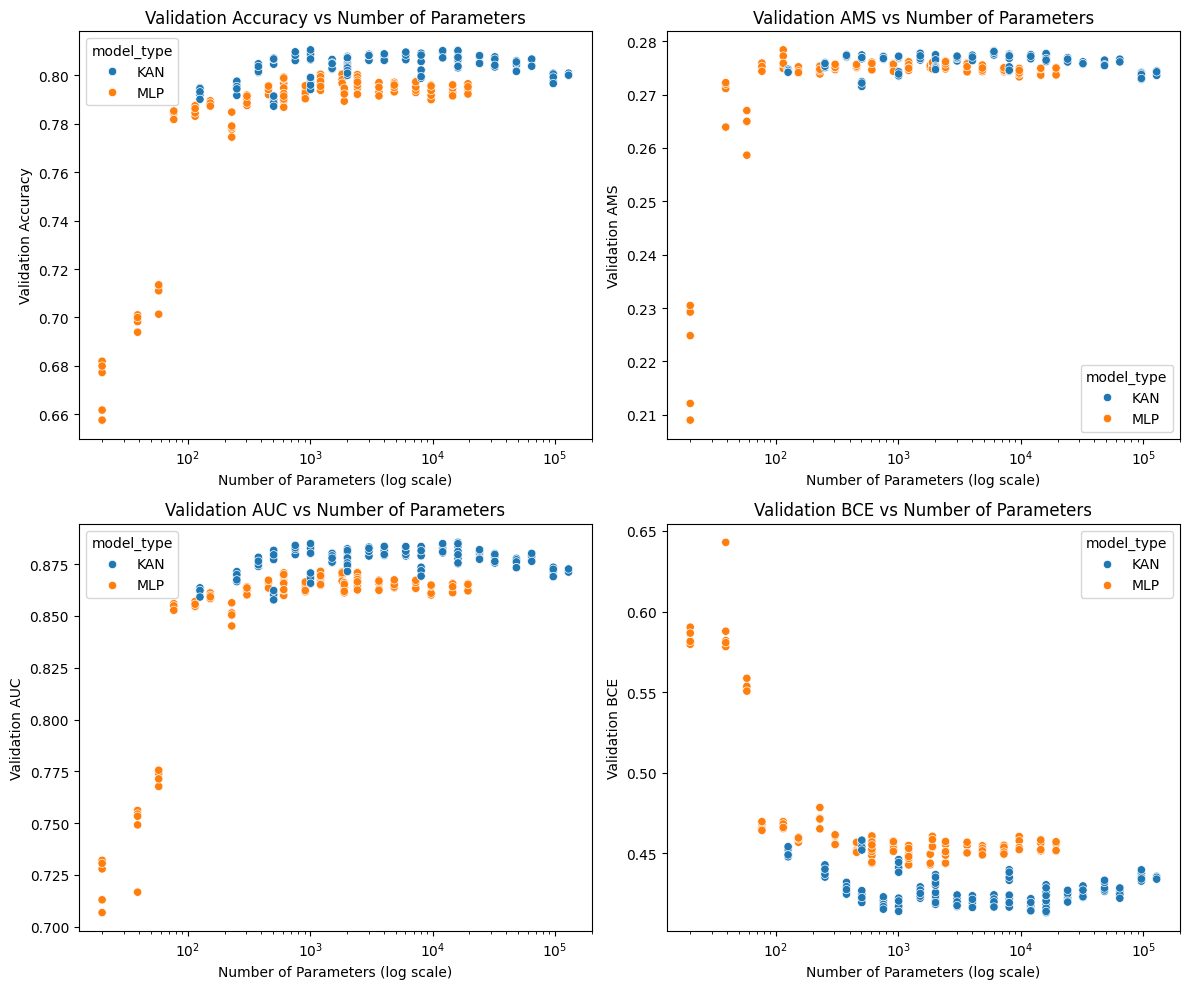

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i, metric in enumerate(val_metric_names):
    r = i // 2
    c = i % 2
    metric_name = metric.replace("val_", "").replace("_epoch", "")
    if metric_name == "loss":
        metric_name = "BCE"
    elif metric_name == "accuracy":
        metric_name = "Accuracy"
    else:
        metric_name = metric_name.upper()

    sns.scatterplot(
        data=df[df["converged"]],
        x="num_params",
        y=f"metrics.{metric}",
        hue="model_type",
        ax=ax[r, c],
    )
    ax[r, c].set_title(f"Validation {metric_name} vs Number of Parameters")
    ax[r, c].set_xlabel("Number of Parameters (log scale)")
    ax[r, c].set_ylabel(f"Validation {metric_name}")
    ax[r, c].set_xscale("log")
plt.tight_layout()

### Convergence Analysis

Finally, we aim at analyzing the convergence speed of both models. For that, we will look at two aspects:
- Number of epochs to converge.
- Wall-clock time to converge.
To do so, we will go run by run, and check at which epoch each model converged (using the same heuristic as before, i.e., checking when the slope of the last 5 epochs is below the threshold).

In [ ]:
def find_convergence_epoch(row: pd.Series, metric: str, n: int = 5) -> int:
    """Find the epoch at which the model converged for a given metric."""
    df = metric_histories[row["run_id"]]

    for epoch in range(n, len(df) + 1):
        last_n = df.dropna(subset=[metric]).sort_values(by="epoch").head(epoch).tail(n)
        if len(last_n) < n:
            continue

        X = last_n["epoch"].values.reshape(-1, 1)
        y = last_n[metric].values

        model = LinearRegression()
        model.fit(X, y)
        slope = model.coef_[0]

        if abs(slope) < thresholds[metric]:
            return epoch
    return -1  # Did not converge within the epochs recorded


for metric in val_metric_names:
    print("Computing convergence epochs for metric:", metric)
    convergence_epoch_column = f"{metric}_convergence_epoch"
    df[convergence_epoch_column] = df.apply(lambda row: find_convergence_epoch(row, metric), axis=1)
    print("Finished computing convergence epochs for metric:", metric)

Computing convergence epochs for metric: val_accuracy_epoch
Finished computing convergence epochs for metric: val_accuracy_epoch
Computing convergence epochs for metric: val_ams_epoch
Finished computing convergence epochs for metric: val_ams_epoch
Computing convergence epochs for metric: val_auc_epoch
Finished computing convergence epochs for metric: val_auc_epoch
Computing convergence epochs for metric: val_loss_epoch
Finished computing convergence epochs for metric: val_loss_epoch


We'll consider that a model has fully converged when all four metrics have converged according to our previous thresholds.

In [28]:
df["full_convergence_epoch"] = df[[f"{metric}_convergence_epoch" for metric in val_metric_names]].max(axis=1)

#### Epochs to Converge as a function of Neurons

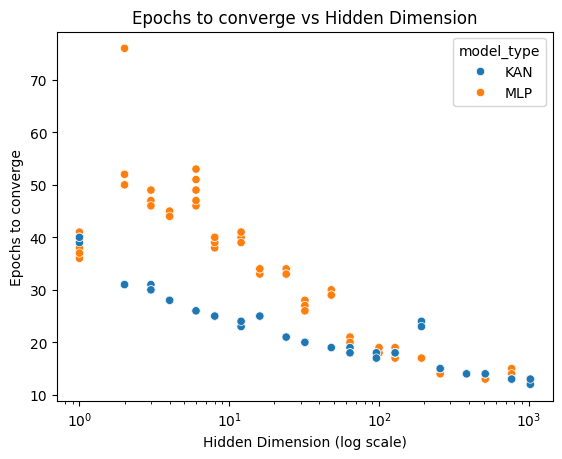

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="params.hidden_dim",
    y="full_convergence_epoch",
    hue="model_type",
)
plt.title("Epochs to converge vs Hidden Dimension")
plt.xlabel("Hidden Dimension (log scale)")
plt.ylabel("Epochs to converge")
plt.xscale("log")

#### Epochs to Converge as a function of Parameters

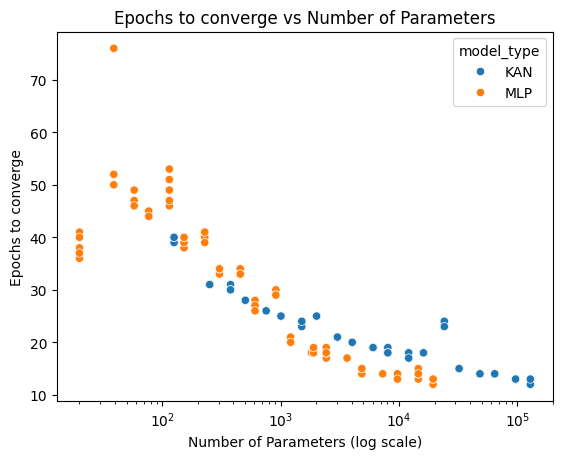

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="num_params",
    y="full_convergence_epoch",
    hue="model_type",
)
plt.title("Epochs to converge vs Number of Parameters")
plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Epochs to converge")
plt.xscale("log")

Unsurprisingly, KANs converge much faster, but when one takes into account all the parameters, they actually take longer.

We can finally compute the same, but for wall-clock time. To do so, we will look at the timestamps logged for each epoch in the histories. We couldn't find the actual way these timestamps are encoded, so we cannot convert them to datetime objects directly (if we could, it would be as easy as subtracting the timestamps from the start_time of the experiments), so we will compute the difference between the timestamp at convergence and the timestamp at epoch 1, to get the total time taken to converge.
To account for that missing "epoch 0" timestamp, we will multiply by `<num_epochs+1>/<num_epochs>`, assuming that the time taken for epoch 0 is similar to the average time taken for the other epochs.

In [100]:
def find_convergence_time(epoch: int, run_id: str) -> float:
    """Find the timestamp at which the model converged for a given metric."""
    df = metric_histories[run_id]
    if epoch == -1:
        return float("nan")
    return (
        pd.Timestamp(df[df["epoch"] == epoch]["timestamp"].values[0], tz="UTC")
        - pd.Timestamp(df[df["epoch"] == 1]["timestamp"].values[0], tz="UTC")
    ).total_seconds() * (
        (epoch + 1) / epoch
    )  # Adjusting for missing epoch 0 time


for metric in val_metric_names:
    convergence_epoch_column = f"{metric}_convergence_epoch"
    convergence_time_column = f"{metric}_convergence_time"
    df[convergence_time_column] = df.apply(
        lambda row: find_convergence_time(row[convergence_epoch_column], row["run_id"]), axis=1
    )

df["full_convergence_time"] = df.apply(
    lambda row: find_convergence_time(row["full_convergence_epoch"], row["run_id"]), axis=1
)

#### Time to Converge as a function of Neurons

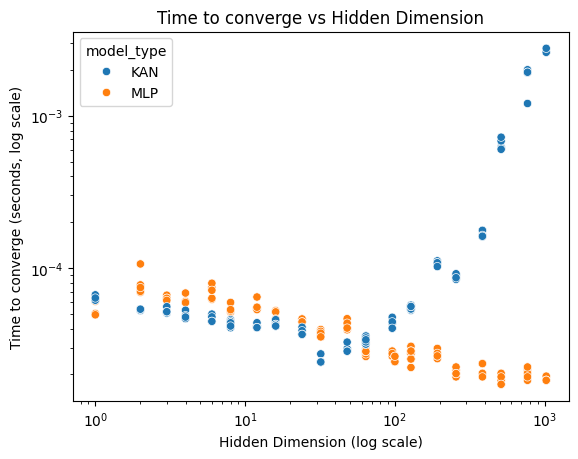

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="params.hidden_dim",
    y="full_convergence_time",
    hue="model_type",
)
plt.title("Time to converge vs Hidden Dimension")
plt.xlabel("Hidden Dimension (log scale)")
plt.ylabel("Time to converge (seconds, log scale)")
plt.xscale("log")
plt.yscale("log")

#### Time to Converge as a function of Parameters

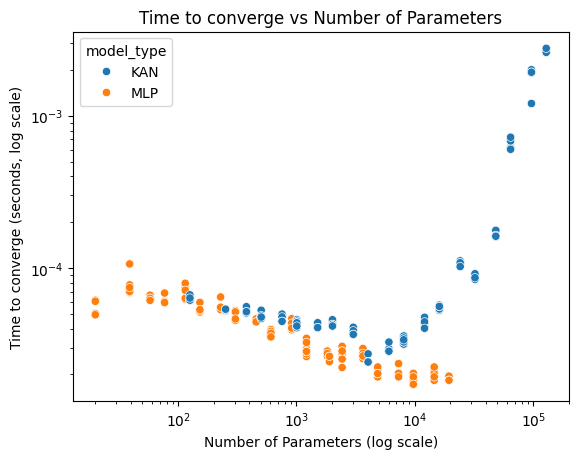

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df[df["converged"]],
    x="num_params",
    y="full_convergence_time",
    hue="model_type",
)
plt.title("Time to converge vs Number of Parameters")
plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Time to converge (seconds, log scale)")
plt.xscale("log")
plt.yscale("log")

Now I feel this is one of the most interesting plots of the entire analysis. It shows that as the number of parameters increases, both MLPs and KANs decrease their time to convergence in a roughly power-law fashion (because in the log-log scale it looks linear) up to some point. After this point, the time to convergence for KANs seems to shoot up extremely fast, while MLPs seem to plateau (or even keep decreasing slightly).

This could suggest that the time complexity of the KANs has some exponential component with regards to the number of neurons that isn't trivial.